In [46]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_digits

digits = load_digits()

X = digits.data

y = digits.target

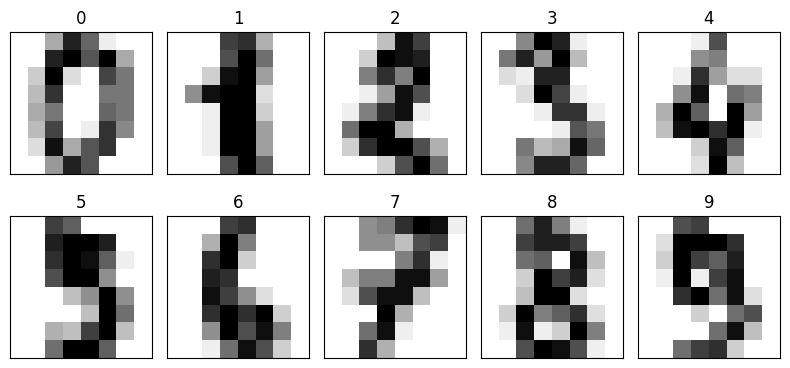

In [47]:
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(8, 4),
                         subplot_kw={'xticks': [], 'yticks': []})


for i, ax in enumerate(axes.flat):
    if i < len(digits.images): 
        ax.imshow(digits.images[i], cmap=plt.cm.binary, interpolation='nearest')
        ax.set_title(str(digits.target[i])) 

plt.tight_layout() 
plt.show()

In [48]:
print(digits.DESCR)

.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 1797
:Number of Attributes: 64
:Attribute Information: 8x8 image of integer pixels in the range 0..16.
:Missing Attribute Values: None
:Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
:Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bitmaps of handwritten digits from a preprinted form. From a
total of 43 people, 30 contributed to the training set and different 13
to the test set. 32x32 bitmaps are divided into nonoverlapping blocks of
4x4 and the number of on pixels are counted in each block. This generates
an in

In [49]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters = 10, init = 'k-means++', random_state = 42)
kmeans.fit(X)


KMeans(n_clusters=10, random_state=42)

There is no need to find an "optimal" K since we are working with a digits dataset we know there should be 10 clusters.

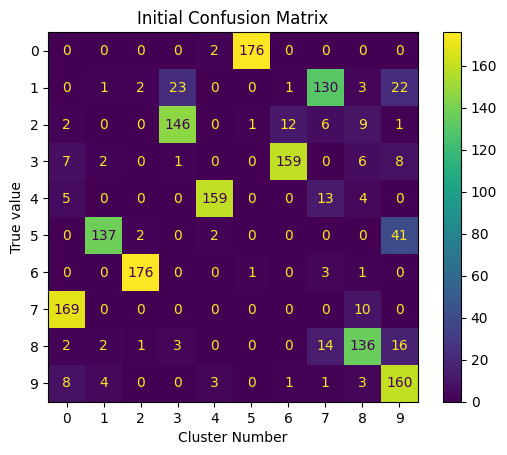

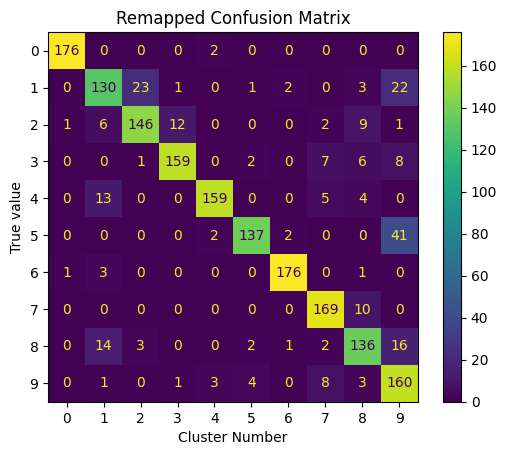

Accuracy Score: 0.8614357262103506


In [65]:
from sklearn.metrics import confusion_matrix, accuracy_score

from sklearn . metrics import ConfusionMatrixDisplay

cluster_assignments = kmeans.labels_
conf_matrix = confusion_matrix(y, cluster_assignments)

display=ConfusionMatrixDisplay ( confusion_matrix=conf_matrix, display_labels=range(0,10))
display.plot()
plt .ylabel("True value")
plt .xlabel("Cluster Number")
plt.title("Initial Confusion Matrix")
plt .show()

cluster_to_label_map = [np.argmax(conf_matrix[:, i]) for i in range(10)]

predicted_labels = np.array([cluster_to_label_map[i] for i in cluster_assignments])

kmeans_conf_matrix=confusion_matrix(y, predicted_labels)
display=ConfusionMatrixDisplay ( confusion_matrix=kmeans_conf_matrix, display_labels=range(0,10))
display.plot()
plt .ylabel("True value")
plt .xlabel("Cluster Number")
plt.title("Remapped Confusion Matrix")
plt .show()
kmeans_accuracy=accuracy_score(y, predicted_labels)
print("Accuracy Score:", kmeans_accuracy)


In [62]:
from sklearn.cluster import AgglomerativeClustering
optimal_clusters = 10
hca_model = AgglomerativeClustering(n_clusters=optimal_clusters, metric='euclidean', linkage='ward')
cluster_labels = hca_model.fit_predict(X)

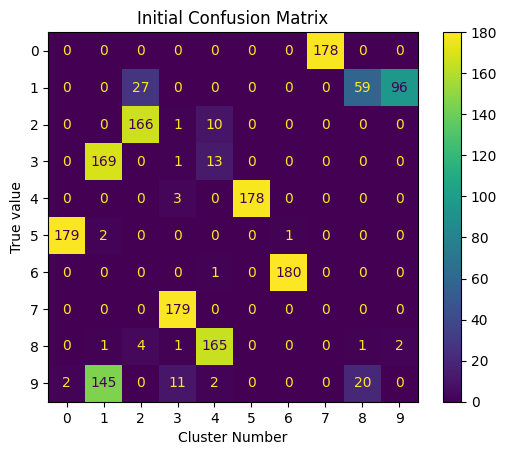

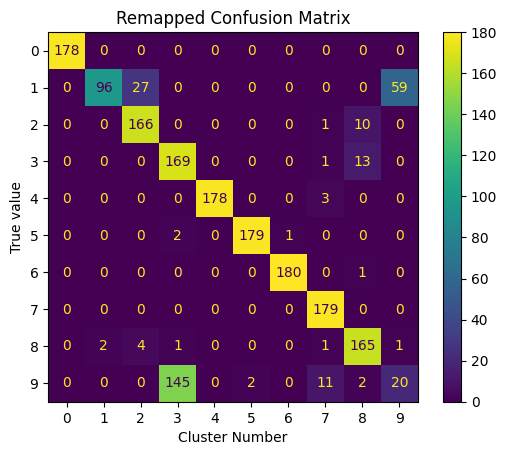

Accuracy Score: 0.8402893711741792


In [63]:

from scipy.optimize import linear_sum_assignment

cluster_assignments = hca_model.labels_


conf_matrix = confusion_matrix(y, cluster_assignments)

display=ConfusionMatrixDisplay ( confusion_matrix=conf_matrix, display_labels=range(0,10))
display.plot()
plt .ylabel("True value")
plt .xlabel("Cluster Number")
plt.title("Initial Confusion Matrix")
plt .show()

def remap_cluster_labels(y_true, y_pred):
    """
    Remaps predicted cluster labels to true labels using the Hungarian algorithm
    to find the optimal one-to-one assignment.
    """
    # Compute the confusion matrix
    # Rows correspond to true labels (0-9), columns to predicted cluster labels (0-9)
    cm = confusion_matrix(y_true, y_pred)
    
    # Use the Hungarian algorithm to find the optimal assignment.
    # We want to maximize the number of correct assignments (maximize the trace of 
    # the reordered confusion matrix), so we use -cm as the cost matrix for minimization.
    row_ind, col_ind = linear_sum_assignment(-cm)
    
    # Create a mapping dictionary: cluster_id (col_ind) -> true_label (row_ind)
    mapping = {col: row for row, col in zip(row_ind, col_ind)}
    
    # Remap the predicted labels
    y_pred_remapped = np.vectorize(mapping.get)(y_pred)
    
    return y_pred_remapped, mapping, cm

predicted_labels,mapping,hca_conf_matrix=remap_cluster_labels(y,cluster_assignments)

hca_conf_matrix=confusion_matrix(y, predicted_labels)

display=ConfusionMatrixDisplay ( confusion_matrix=hca_conf_matrix, display_labels=range(0,10))
display.plot()
plt .ylabel("True value")
plt .xlabel("Cluster Number")
plt.title("Remapped Confusion Matrix")
plt .show()
hca_accuracy=accuracy_score(y, predicted_labels)
print("Accuracy Score:", hca_accuracy)

## Comparison:
both models have similar accuracy (86% and 84%) however the Kmeans model misclassifications were spread out over all the digits whereas the HCA model performed very well in all the digits but almost completely misclassified the digit 9 as 3.

## Conclusion:
while both models achieve similar accuracy between 84% and 86%, they exhibit distinct failure patterns due to their underlying logic. 
K-Means shows a distributed "blurriness" with misclassifications spread across all digits, whereas HCA demonstrates a cleaner separation for most numbers but suffers from a major  blind spot, almost completely misclassifying 9s as 3s. This specific HCA error likely comes from the 8x8 resolution, where the geometric "skeletons" of 9 and 3 are nearly the same, causing the hierarchical tree to merge them early without the possibility of later separation.